# ✔️ 사전 세팅

In [ ]:
# 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 21 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,974 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 124926 files and dire

In [ ]:
pip install torchinfo

In [ ]:
import os
import math
import glob
import warnings
import random
import shutil

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from PIL import Image, ImageEnhance, ImageFilter

from sklearn.metrics import classification_report
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data.sampler import WeightedRandomSampler
from torchinfo import summary

import torchvision.models as models
import torchvision.transforms.v2 as v2
from torchvision import transforms, datasets

import kagglehub

In [ ]:
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

# Warnings 제거
warnings.filterwarnings('ignore')

# Google drive 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Pandas 보기 옵션
pd.set_option('display.max_columns',100)

In [ ]:
# 폰트 설정
plt.figure(figsize=(20, 15))
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

<Figure size 2000x1500 with 0 Axes>

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 21 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---

# ✔️ 요약

본 실습에서는 흉부 X-ray 이미지를 활용한 **폐렴(Pneumonia) 분류 모델**을 구축했다. <br>
기존의 Custom CNN 모델과 ResNet18 기반 Transfer Learning 기법을 비교 실험하였으며,<br>
모델 학습 성능을 향상시키기 위해 **Feature Extraction, Partial Fine-Tuning, Full Fine-Tuning**을 단계적으로 적용하였다.

또한, 클래스 불균형 문제를 해결하기 위해 Weighted Sampling 기법을 도입하여 데이터 분포를 조정하고,<br>
데이터 증강을 적용하여 모델의 일반화 성능을 높였다.

실험 결과, **Full Fine-Tuning 모델이 가장 높은 정확도와 균형 잡힌 성능**을 보여 최적의 모델로 판단했다.

---

# ✔️ 1. 데이터 분석

### 데이터 설명

**1) 목적** <br>
본 프로젝트는 **흉부 X-Ray 사진을 바탕으로 폐렴 환자를 구분**하는 분류 모델 개발을 목표로 한다. <br>
이를 위해 다양한 이미지 전처리 및 증강 기법을 적용하고, Transfer Learning 및 Fine-Tuning 기법을 활용하여 모델 성능을 평가할 것이다.

<br>

**2) 데이터셋** <br>
본 프로젝트에서는 **Chest X-Ray Images (Pneumonia) 데이터셋**을 사용하며, <br>
데이터는 훈련(train), 검증(val), 테스트(test)로 구성되어 있다.

### 데이터 불러오기

In [ ]:
# 기존 데이터가 있다면 삭제 (초기화)
if os.path.exists("/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia"):
    shutil.rmtree("/root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia")

In [ ]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

100%|██████████| 2.29G/2.29G [00:22<00:00, 110MB/s] 

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


### 데이터 개수 확인

In [ ]:
dataset_path = os.path.join(path, "chest_xray")

def count_images(directory):
    categories = ["train", "test", "val"]
    for category in categories:
        normal_path = os.path.join(directory, category, "NORMAL")
        pneumonia_path = os.path.join(directory, category, "PNEUMONIA")

        num_normal = len(os.listdir(normal_path))
        num_pneumonia = len(os.listdir(pneumonia_path))

        print(f"{category} - 정상: {num_normal}개, 폐렴: {num_pneumonia}개")

count_images(dataset_path)

train - 정상: 1341개, 폐렴: 3875개
test - 정상: 234개, 폐렴: 390개
val - 정상: 8개, 폐렴: 8개


val 데이터의 개수가 매우 적다. <br>
추후 데이터셋 간 개수 조정을 해야할 것 같다.

### 데이터 크기 확인

In [ ]:
sample_image_path = os.path.join(dataset_path, "train/NORMAL", os.listdir(os.path.join(dataset_path, "train/NORMAL"))[0])
image = cv2.imread(sample_image_path)

height, width, channels = image.shape
print(f"이미지 크기: ({width}x{height})")
print(f"채널: {channels}")

이미지 크기: (1754x1341)
채널: 3


### 데이터 샘플 확인

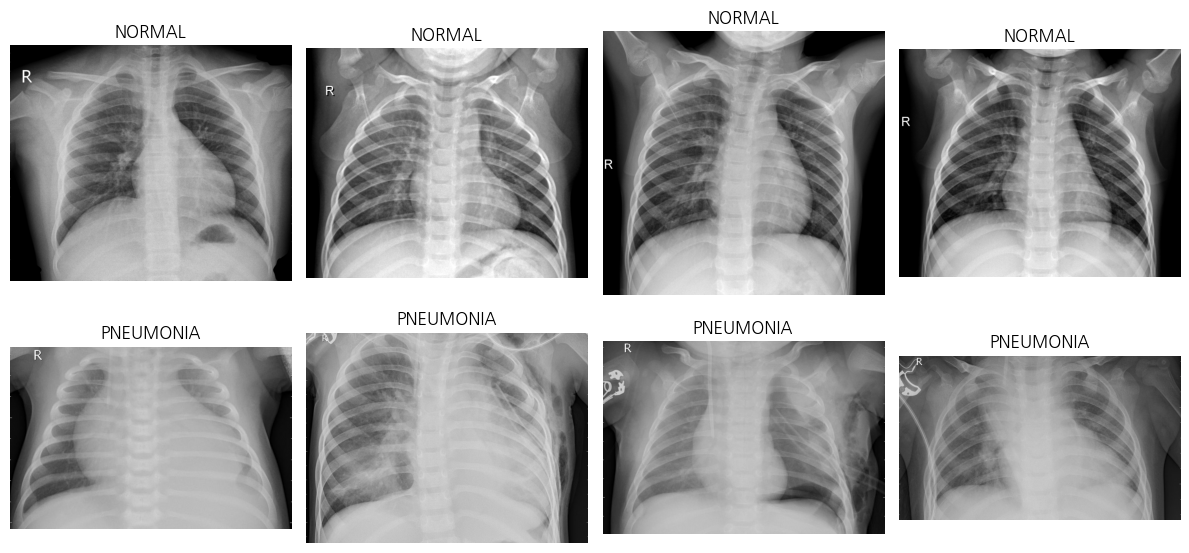

In [ ]:
def show_samples(category="train"):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    for i, label in enumerate(["NORMAL", "PNEUMONIA"]):
        img_dir = os.path.join(dataset_path, category, label)
        sample_files = random.sample(os.listdir(img_dir), 4)

        for j, file in enumerate(sample_files):
            img_path = os.path.join(img_dir, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].set_title(f"{label}")
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples("train")

---

# ✔️ 2. 데이터 전처리

### 데이터 개수 조정

train, test, val의 데이터 비율이 맞지 않는 상태이다. <br>
이를 재조정하여 기존 train 데이터의 10%를 val 데이터로 이동시킬 것이다.

In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

# train의 10%를 val로 이동
val_split = 0.1

def move_data(label):
    train_path = os.path.join(train_dir, label)
    val_path = os.path.join(val_dir, label)

    files = os.listdir(train_path)
    num_to_move = int(len(files) * val_split)

    val_files = random.sample(files, num_to_move)
    for file in val_files:
        shutil.move(os.path.join(train_path, file), os.path.join(val_path, file))

    print(f"{label} - {num_to_move}개 이동")

move_data("NORMAL")
move_data("PNEUMONIA")


# 결과 확인
print("==========================")
dataset_path = os.path.join(path, "chest_xray")

def count_images(directory):
    categories = ["train", "test", "val"]
    for category in categories:
        normal_path = os.path.join(directory, category, "NORMAL")
        pneumonia_path = os.path.join(directory, category, "PNEUMONIA")

        num_normal = len(os.listdir(normal_path))
        num_pneumonia = len(os.listdir(pneumonia_path))

        print(f"{category} - 정상: {num_normal}개, 폐렴: {num_pneumonia}개")

count_images(dataset_path)

NORMAL - 134개 이동
PNEUMONIA - 387개 이동
train - 정상: 1207개, 폐렴: 3488개
test - 정상: 234개, 폐렴: 390개
val - 정상: 142개, 폐렴: 395개


val 데이터의 수가 늘어난 것을 확인할 수 있다.

### 데이터 전처리 정의

**데이터 증강**
- 다음코드에서 회전은 삭제하기 바람

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        # 데이터 증강
        transforms.RandomRotation(20),  # 회전
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # 이동
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'test': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
}

모델 성능 향상을 위해 **훈련 데이터(train)**에는 **회전, 좌우 반전, 이동을 추가하여 데이터를 증강**했다. <br>
**검증(val) 및 테스트(test) 데이터**는 평가의 일관성을 위해 증강 없이 **크기 조정 및 정규화만 적용**하였다.

### 데이터로더(DataLoader) 생성

**가중치 기반 샘플링**

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# 클래스별 샘플 수 계산
class_counts = [len(os.listdir(os.path.join(train_dir, "NORMAL"))),
                len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))]

# 클래스 가중치 계산
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for _, label in train_dataset.imgs]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"training 데이터 수: {len(train_dataset)}")
print(f"validation 데이터 수: {len(val_dataset)}")
print(f"test 데이터 수: {len(test_dataset)}")

training 데이터 수: 4695
validation 데이터 수: 537
test 데이터 수: 624


본 데이터셋에는 클래스 불균형 문제가 있기 때문에, **가중치 기반 샘플링**(Weighted Sampling)을 적용하였다. <br>
먼저, 훈련 데이터에서 정상(NORMAL)과 폐렴(PNEUMONIA) 클래스별 샘플 수를 계산했다. <br><br>
이후, **샘플이 적은 클래스에 더 높은 가중치를 부여**하기 위해 클래스 가중치(class_weights)를 계산하고, <br>
이를 기반으로 각 샘플에 가중치를 적용하였다. <br><br>

<기본 CNN 모델 테스트 결과><br>
가중치 기반 샘플링을 적용하지 않은 경우, Normal 클래스의 Recall과 F1-score가 40%-50%로 낮게 나타났다. <br>
그러나 **가중치 기반 샘플링을 적용한 후에는 60%-70%로 성능이 향상**됨을 확인했다. <br>
따라서 최종적으로는 가중치 기반 샘플링을 적용하기로 결정했다.

### 전처리 결과 확인

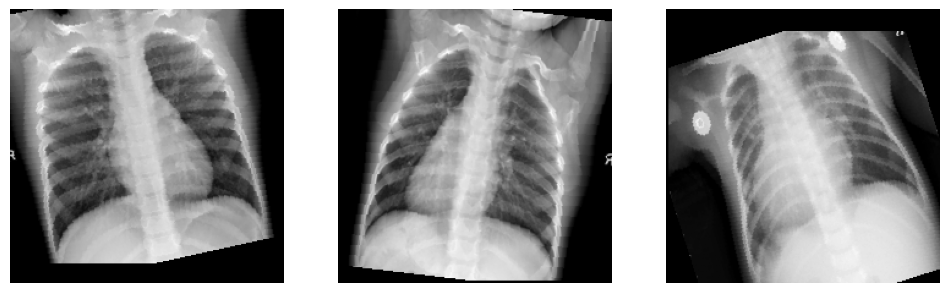

In [ ]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

num_samples = 3

fig, axes = plt.subplots(1, num_samples, figsize=(12, 4))

for i in range(num_samples):
    img = images[i].numpy().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].axis("off")
plt.show()

이미지가 동일한 크기로 리사이징 되었으며, <br>
데이터 증강 또한 잘 적용되었음을 확인할 수 있다.

---

# ✔️ 3. CustomCNN 모델 생성

### 모델 설계

Transfer Learning를 하기 전, 기본이 될 CustomCNN 모델을 만들었다.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 모델 생성
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN(num_classes=2).to(device)
summary(model, input_size=(1, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CustomCNN                                [1, 2]                    --
├─Conv2d: 1-1                            [1, 32, 224, 224]         320
├─BatchNorm2d: 1-2                       [1, 32, 224, 224]         64
├─MaxPool2d: 1-3                         [1, 32, 112, 112]         --
├─Conv2d: 1-4                            [1, 64, 112, 112]         18,496
├─BatchNorm2d: 1-5                       [1, 64, 112, 112]         128
├─MaxPool2d: 1-6                         [1, 64, 56, 56]           --
├─Conv2d: 1-7                            [1, 128, 56, 56]          73,856
├─BatchNorm2d: 1-8                       [1, 128, 56, 56]          256
├─MaxPool2d: 1-9                         [1, 128, 28, 28]          --
├─Conv2d: 1-10                           [1, 128, 28, 28]          147,584
├─BatchNorm2d: 1-11                      [1, 128, 28, 28]          256
├─MaxPool2d: 1-12                        [1, 128, 14, 14]          -

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

**손실 함수는 CrossEntropyLoss**를 사용하여 모델의 예측과 실제 정답 간의 차이를 최소화하도록 했다. <br>
**최적화 알고리즘으로는 Adam**을 사용하여 안정적인 학습을 하도록 했다.

### 모델 학습

In [ ]:
epochs = 10

def train_model(model, train_loader, val_loader, loss_fn, optimizer, device, epochs):
    model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        correct, total = 0, 0

        for batch_inputs, batch_labels in train_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)

            optimizer.zero_grad()
            outputs = model(batch_inputs)
            loss = loss_fn(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_labels).sum().item()
            total += batch_labels.size(0)

        train_acc = correct / total
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        val_loss, val_acc = evaluate_model(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_losses, val_losses

### 모델 평가

In [ ]:
def evaluate_model(model, dataloader, loss_fn, device, final_report=False):
    model.to(device)
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = sum(1 for x, y in zip(all_preds, all_labels) if x == y) / len(all_labels)

    if final_report:
        class_names = ["Normal", "Pneumonia"]
        report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
        print(f"\nFinal Test Accuracy: {accuracy:.4f}")
        print(report)

    return avg_loss, accuracy

### 결과

Epoch [1/10] | Train Loss: 0.3654, Train Acc: 0.8635, Val Loss: 0.4120, Val Acc: 0.8175
Epoch [2/10] | Train Loss: 0.2776, Train Acc: 0.8976, Val Loss: 0.5903, Val Acc: 0.7449
Epoch [3/10] | Train Loss: 0.2495, Train Acc: 0.9048, Val Loss: 0.2076, Val Acc: 0.9088
Epoch [4/10] | Train Loss: 0.2219, Train Acc: 0.9191, Val Loss: 0.7261, Val Acc: 0.7412
Epoch [5/10] | Train Loss: 0.2217, Train Acc: 0.9201, Val Loss: 0.1617, Val Acc: 0.9423
Epoch [6/10] | Train Loss: 0.1849, Train Acc: 0.9310, Val Loss: 0.1614, Val Acc: 0.9330
Epoch [7/10] | Train Loss: 0.1942, Train Acc: 0.9267, Val Loss: 0.1677, Val Acc: 0.9385
Epoch [8/10] | Train Loss: 0.1626, Train Acc: 0.9384, Val Loss: 0.1990, Val Acc: 0.9311
Epoch [9/10] | Train Loss: 0.1668, Train Acc: 0.9408, Val Loss: 0.1287, Val Acc: 0.9479
Epoch [10/10] | Train Loss: 0.1472, Train Acc: 0.9468, Val Loss: 0.1638, Val Acc: 0.9460


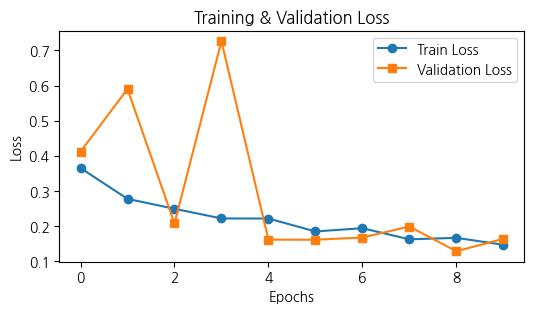

In [ ]:
# 모델 학습
train_losses, val_losses = train_model(model, train_loader, val_loader, loss_fn, optimizer, device, epochs)

# 손실 그래프 출력
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

특정 에포크에서 Validation Loss가 급격히 증가했다가 다시 감소하는 패턴이 보인다. <br>
모델이 특정 데이터에 과적합하고 있을 것으로 추측한다.

In [ ]:
test_loss, test_acc = evaluate_model(model, test_loader, loss_fn, device, final_report=True)
print(f"Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.8462
              precision    recall  f1-score   support

      Normal     0.9107    0.6538    0.7612       234
   Pneumonia     0.8224    0.9615    0.8865       390

    accuracy                         0.8462       624
   macro avg     0.8665    0.8077    0.8239       624
weighted avg     0.8555    0.8462    0.8395       624

Test Accuracy: 0.8462


CustomCNN 모델의 **정확도는 84.62%**이다. <br>
Pneumonia 클래스는 전반적으로 잘 예측했지만, **Normal 클래스의 Recall(65.38%)이 낮아** 정상 데이터를 놓치는 경향이 나타났다. <br>


전반적으로 클래스 간 성능 불균형이 있으며, 정상 환자를 놓칠 가능성이 높아 실전 적용에는 한계가 있다.

### 예측 시각화

Normal 클래스와 Pneumonia 클래스에서 각각 랜덤으로 5개의 데이터를 골라 시각화했다.

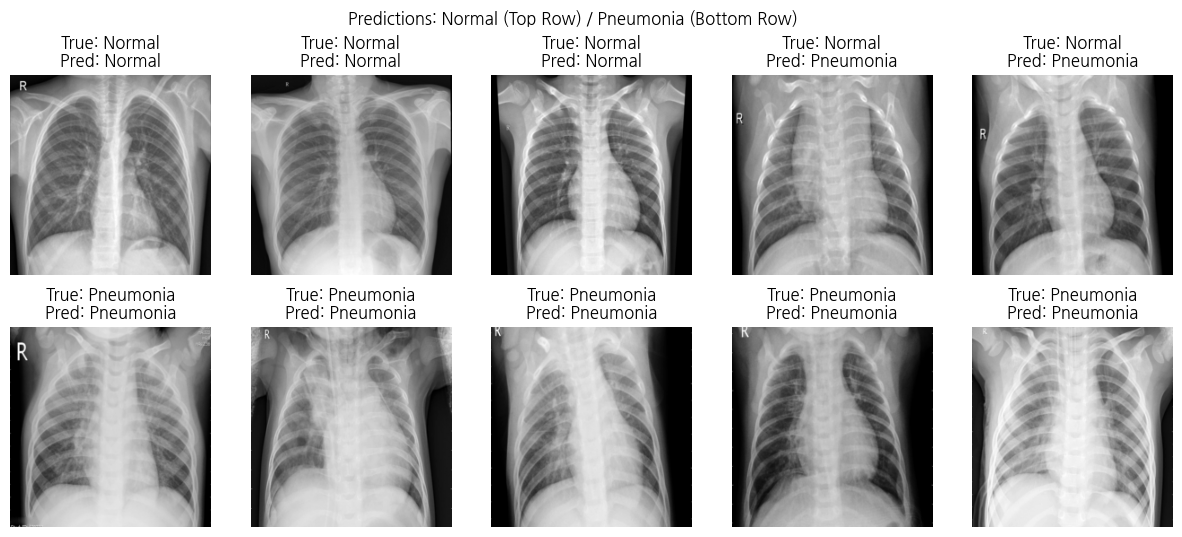

In [ ]:
def visualize_predictions_balanced(model, test_loader, num_samples_per_class=5):
    model.eval()
    images, labels, preds = [], [], []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            images.extend(inputs.cpu())
            labels.extend(targets.cpu().numpy())
            preds.extend(predicted.cpu().numpy())

    images = torch.stack(images)
    labels = list(labels)
    preds = list(preds)

    class_names = ["Normal", "Pneumonia"]

    # Normal 5개, Pneumonia 5개 선택
    normal_indices = [i for i in range(len(labels)) if labels[i] == 0]
    pneumonia_indices = [i for i in range(len(labels)) if labels[i] == 1]

    selected_normals = random.sample(normal_indices, num_samples_per_class)
    selected_pneumonias = random.sample(pneumonia_indices, num_samples_per_class)

    selected_indices = selected_normals + selected_pneumonias

    fig, axes = plt.subplots(2, num_samples_per_class, figsize=(15, 6))

    for i, idx in enumerate(selected_indices):
        img = images[idx].squeeze().numpy()
        row = 0 if i < num_samples_per_class else 1
        col = i % num_samples_per_class

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"True: {class_names[labels[idx]]}\nPred: {class_names[preds[idx]]}")
        axes[row, col].axis("off")

    plt.suptitle("Predictions: Normal (Top Row) / Pneumonia (Bottom Row)")
    plt.show()

# 시각화
visualize_predictions_balanced(model, test_loader, num_samples_per_class=5)

---

# ✔️ 4. Feature Extraction 실험

본 실습에서는 **사전 학습된 ResNet18 모델**을 활용하여 폐렴 분류 성능을 향상시키고자 한다. <br><br>
먼저 **X-Ray 이미지는 흑백(Grayscale)**이므로, <br>
원본 ResNet의 첫 번째 합성곱 층(Conv1)만 **입력 채널을 3 → 1로 수정**하여 단일 채널 이미지에 대응하도록 변경했다. <br><br>
또한, **기존 FC Layer를 2개 클래스(Normal, Pneumonia)**를 분류하는 새로운 출력층으로 교체했다. <br>
이를 통해 사전 학습된 특징을 활용하면서도, 폐렴 분류에 적합한 맞춤형 모델을 구축하였다.

In [ ]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# ResNet 입력 채널 3 → 1로 수정
pretrained_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# 2개 클래스(Normal vs Pneumonia)로 분류하도록 수정
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_ftrs, 2)

print(pretrained_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Convolutional Layers는 고정(Freeze)하고, 마지막 FC Layer만 학습 가능하도록 설정했다.

In [ ]:
# Convolutional Layer는 고정
for param in pretrained_model.parameters():
    param.requires_grad = False

# FC Layer는 학습 가능
for param in pretrained_model.fc.parameters():
    param.requires_grad = True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(pretrained_model.fc.parameters(), lr=0.001)

Epoch [1/10] | Train Loss: 0.4528, Train Acc: 0.8032, Val Loss: 0.3842, Val Acc: 0.8287
Epoch [2/10] | Train Loss: 0.3371, Train Acc: 0.8645, Val Loss: 0.3472, Val Acc: 0.8361
Epoch [3/10] | Train Loss: 0.2974, Train Acc: 0.8818, Val Loss: 0.2967, Val Acc: 0.8585
Epoch [4/10] | Train Loss: 0.2975, Train Acc: 0.8829, Val Loss: 0.3049, Val Acc: 0.8641
Epoch [5/10] | Train Loss: 0.2741, Train Acc: 0.8878, Val Loss: 0.3496, Val Acc: 0.8454
Epoch [6/10] | Train Loss: 0.2906, Train Acc: 0.8822, Val Loss: 0.2969, Val Acc: 0.8678
Epoch [7/10] | Train Loss: 0.2694, Train Acc: 0.8912, Val Loss: 0.3387, Val Acc: 0.8454
Epoch [8/10] | Train Loss: 0.2704, Train Acc: 0.8873, Val Loss: 0.3750, Val Acc: 0.8343
Epoch [9/10] | Train Loss: 0.2614, Train Acc: 0.8978, Val Loss: 0.2997, Val Acc: 0.8715
Epoch [10/10] | Train Loss: 0.2788, Train Acc: 0.8863, Val Loss: 0.3031, Val Acc: 0.8678


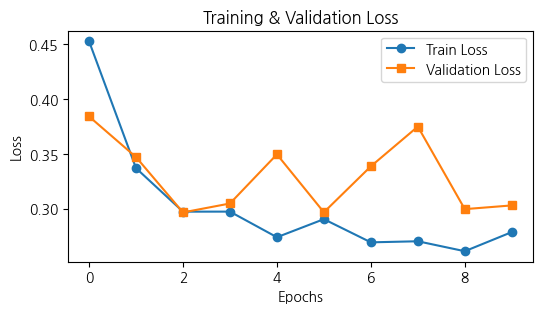

In [ ]:
# 사전 학습된 ResNet18 모델을 활용한 모델 학습
train_losses, val_losses = train_model(pretrained_model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10)

# 학습 결과 시각화
plt.figure(figsize=(6,3))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

Feature Extraction에서도 특정 에포크에서 Validation Loss가 급격히 증가했다가 다시 감소하는 패턴이 보인다. <br>
CustomCNN에서만 나타나는 현상이라고 예측했지만, Feature **Extraction에서도 동일한 패턴을 보여 모델의 과적합**이라고 판단했다. <br>
이에 따라 CustomCNN 모델 구조를 축소하려고 했지만, GPU가 부족하여 수행하지 못한 점이 아쉬움으로 남는다.

In [ ]:
# 모델 평가
test_loss, test_acc = evaluate_model(pretrained_model, test_loader, loss_fn, device, final_report=True)
print(f"Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.8317
              precision    recall  f1-score   support

      Normal     0.8146    0.7137    0.7608       234
   Pneumonia     0.8401    0.9026    0.8702       390

    accuracy                         0.8317       624
   macro avg     0.8274    0.8081    0.8155       624
weighted avg     0.8305    0.8317    0.8292       624

Test Accuracy: 0.8317


Feature Extraction 모델의 **정확도는 83.17%**로, CustomCNN과 유사한 성능을 보였다. <br>
Normal 클래스의 Recall이 71.37%로 증가하여 정상 데이터를 놓치는 문제는 다소 개선되었으나, <br>
Precision(81.46%)이 감소하여 오탐이 증가했다. <br><br>
전반적으로 CustomCNN보다 안정적인 성능을 보였으나, 성능 향상이 크지는 않았다.

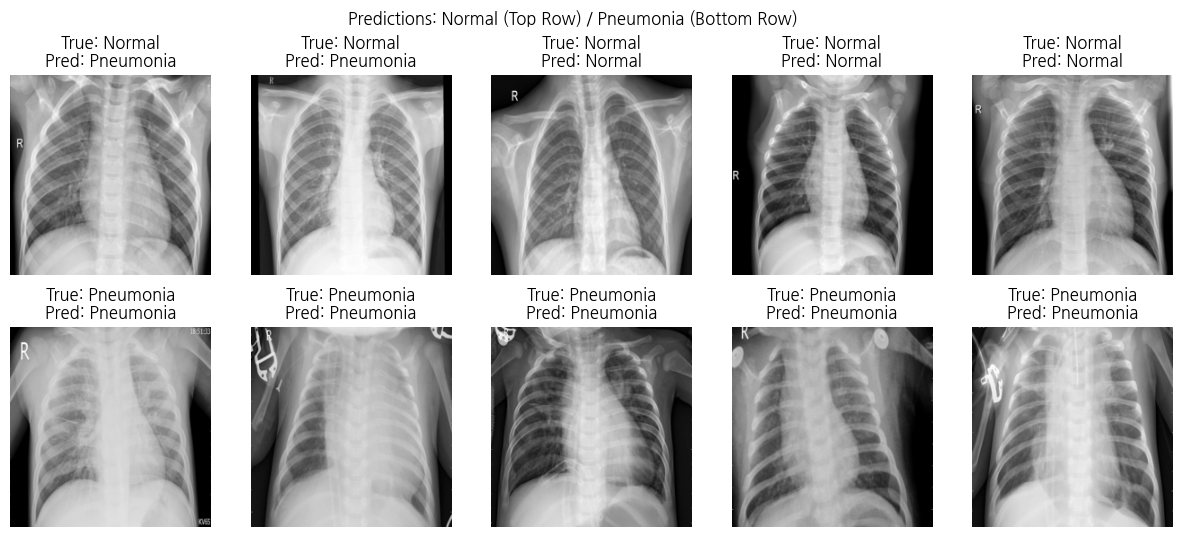

In [ ]:
# 테스트 결과 시각화 (Normal 5개, Pneumonia 5개)
visualize_predictions_balanced(pretrained_model, test_loader, num_samples_per_class=5)

---

# ✔️ 5. Fine-Tuning 실험

### 1) Partial Fine-Tuning 모델

Partial Fine-Tuning 모델도 마찬가지로, <br>
원본 ResNet의 첫 번째 합성곱 층(Conv1)만 **입력 채널을 3 → 1로 수정**하여 단일 채널 이미지에 대응하도록 변경했다. <br>
또한, **기존 FC Layer를 2개 클래스(Normal, Pneumonia)**를 분류하는 새로운 출력층으로 교체했다. <br><br>

사전 학습된 ResNet18 모델의 **가중치(파라미터)를 잃지 않도록 state_dict**를 추가했다.

In [ ]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 기존 모델의 가중치 저장
state_dict = pretrained_model.state_dict()

# ResNet 입력 채널 3 → 1로 수정
new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
pretrained_model.conv1 = new_conv1

pretrained_model.conv1.weight.data = state_dict["conv1.weight"][:, :1, :, :]
filtered_state_dict = {k: v for k, v in state_dict.items() if not k.startswith("conv1")}
pretrained_model.load_state_dict(filtered_state_dict, strict=False)

# 2개 클래스(Normal vs Pneumonia)로 분류하도록 수정
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_ftrs, 2)

print(pretrained_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

마지막 Conv 블록(layer4)과 FC Layer만 학습 가능하도록 설정했다.

In [ ]:
# Convolutional Layer를 고정
for param in pretrained_model.parameters():
    param.requires_grad = False

# Block4와 FC Layer만 학습 가능
for name, param in pretrained_model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, pretrained_model.parameters()), lr=0.0005)

Epoch [1/10] | Train Loss: 0.1678, Train Acc: 0.9384, Val Loss: 0.1670, Val Acc: 0.9441
Epoch [2/10] | Train Loss: 0.0805, Train Acc: 0.9734, Val Loss: 0.1226, Val Acc: 0.9572
Epoch [3/10] | Train Loss: 0.0750, Train Acc: 0.9715, Val Loss: 0.1372, Val Acc: 0.9460
Epoch [4/10] | Train Loss: 0.0531, Train Acc: 0.9806, Val Loss: 0.0920, Val Acc: 0.9683
Epoch [5/10] | Train Loss: 0.0543, Train Acc: 0.9789, Val Loss: 0.1292, Val Acc: 0.9534
Epoch [6/10] | Train Loss: 0.0425, Train Acc: 0.9836, Val Loss: 0.0527, Val Acc: 0.9795
Epoch [7/10] | Train Loss: 0.0494, Train Acc: 0.9819, Val Loss: 0.2026, Val Acc: 0.9423
Epoch [8/10] | Train Loss: 0.0491, Train Acc: 0.9802, Val Loss: 0.1198, Val Acc: 0.9721
Epoch [9/10] | Train Loss: 0.0473, Train Acc: 0.9815, Val Loss: 0.0750, Val Acc: 0.9814
Epoch [10/10] | Train Loss: 0.0392, Train Acc: 0.9868, Val Loss: 0.1958, Val Acc: 0.9516


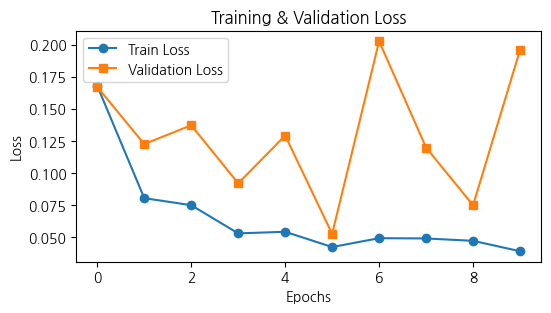

In [ ]:
# 사전 학습된 ResNet18 모델을 활용한 모델 학습
train_losses, val_losses = train_model(pretrained_model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10)

# 학습 결과 시각화
plt.figure(figsize=(6,3))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

Partial Fine-Tuning 모델도 특정 에포크에서 Validation Loss가 급격히 증가했다가 다시 감소하는 패턴이 보인다. <br>

In [ ]:
# 모델 평가
test_loss, test_acc = evaluate_model(pretrained_model, test_loader, loss_fn, device, final_report=True)
print(f"Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.9183
              precision    recall  f1-score   support

      Normal     0.9140    0.8632    0.8879       234
   Pneumonia     0.9206    0.9513    0.9357       390

    accuracy                         0.9183       624
   macro avg     0.9173    0.9073    0.9118       624
weighted avg     0.9181    0.9183    0.9178       624

Test Accuracy: 0.9183


Partial Fine-Tuning 모델의 **정확도는 91.83%**로 성능이 크게 향상되었다. <br>
Normal 클래스의 Recall이 86.32%까지 증가하여 **정상 데이터를 놓치는 문제가 많이 개선**되었고, Precision도 91.40%로 유지되었다. <br>
Pneumonia 클래스도 Recall 95.13%, Precision 92.06%로 **균형 잡힌 성능**을 보였다. <br><br>
Feature Extraction보다 특징을 잘 학습하여 전반적인 성능이 향상되었으며, 일반화 성능이 우수하다.

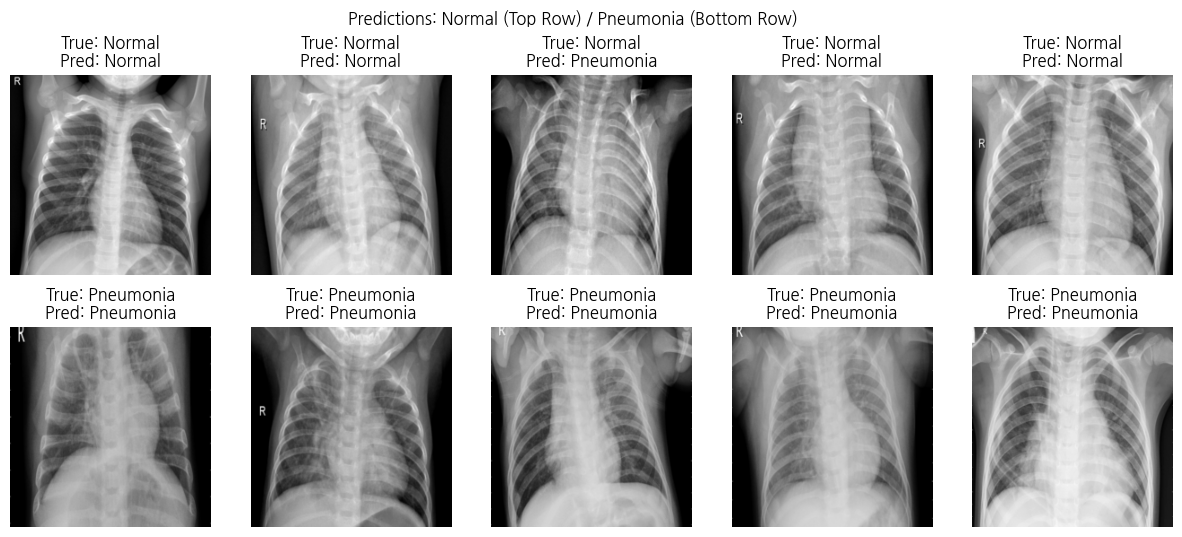

In [ ]:
# 테스트 결과 시각화 (Normal 5개, Pneumonia 5개)
visualize_predictions_balanced(pretrained_model, test_loader, num_samples_per_class=5)

### 2) Full Fine-Tuning 모델

Full Fine-Tuning 모델도 마찬가지로, <br>
원본 ResNet의 첫 번째 합성곱 층(Conv1)만 **입력 채널을 3 → 1로 수정**하여 단일 채널 이미지에 대응하도록 변경했다. <br>
또한, **기존 FC Layer를 2개 클래스(Normal, Pneumonia)**를 분류하는 새로운 출력층으로 교체했다. <br><br>

사전 학습된 ResNet18 모델의 **가중치(파라미터)를 잃지 않도록 state_dict**를 추가했다.

In [ ]:
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 기존 모델의 가중치 저장
state_dict = pretrained_model.state_dict()

# ResNet 입력 채널 3 → 1로 수정
new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
pretrained_model.conv1 = new_conv1

pretrained_model.conv1.weight.data = state_dict["conv1.weight"][:, :1, :, :]
filtered_state_dict = {k: v for k, v in state_dict.items() if not k.startswith("conv1")}
pretrained_model.load_state_dict(filtered_state_dict, strict=False)

# 2개 클래스(Normal vs Pneumonia)로 분류하도록 수정
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_ftrs, 2)

모든 레이어를 학습 가능하도록 설정했다.

In [ ]:
#  모든 레이어 학습 가능
for param in pretrained_model.parameters():
    param.requires_grad = True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(pretrained_model.parameters(), lr=0.0001)  # Fine-Tuning 시 학습률을 낮춤

Epoch [1/10] | Train Loss: 0.1354, Train Acc: 0.9480, Val Loss: 0.1221, Val Acc: 0.9590
Epoch [2/10] | Train Loss: 0.0681, Train Acc: 0.9749, Val Loss: 0.1029, Val Acc: 0.9702
Epoch [3/10] | Train Loss: 0.0629, Train Acc: 0.9764, Val Loss: 0.1586, Val Acc: 0.9553
Epoch [4/10] | Train Loss: 0.0497, Train Acc: 0.9830, Val Loss: 0.0698, Val Acc: 0.9739
Epoch [5/10] | Train Loss: 0.0434, Train Acc: 0.9842, Val Loss: 0.2314, Val Acc: 0.9330
Epoch [6/10] | Train Loss: 0.0348, Train Acc: 0.9868, Val Loss: 0.0914, Val Acc: 0.9702
Epoch [7/10] | Train Loss: 0.0335, Train Acc: 0.9876, Val Loss: 0.0792, Val Acc: 0.9702
Epoch [8/10] | Train Loss: 0.0204, Train Acc: 0.9928, Val Loss: 0.1087, Val Acc: 0.9702
Epoch [9/10] | Train Loss: 0.0269, Train Acc: 0.9908, Val Loss: 0.1227, Val Acc: 0.9628
Epoch [10/10] | Train Loss: 0.0194, Train Acc: 0.9942, Val Loss: 0.1528, Val Acc: 0.9628


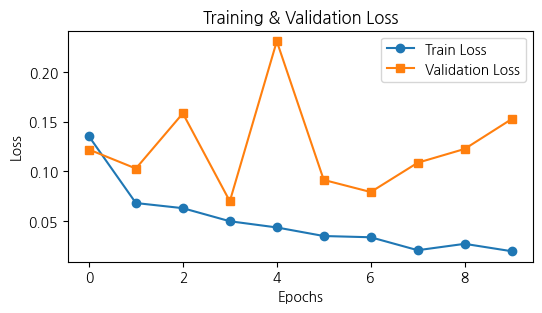

In [ ]:
# 사전 학습된 ResNet18 모델을 활용한 모델 학습
train_losses, val_losses = train_model(pretrained_model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10)

# 학습 결과 시각화
plt.figure(figsize=(6,3))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Validation Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

Full Fine-Tuning 모델도 특정 에포크에서 Validation Loss가 급격히 증가했다가 다시 감소하는 패턴이 보인다. <br>

In [ ]:
# 모델 평가
test_loss, test_acc = evaluate_model(pretrained_model, test_loader, loss_fn, device, final_report=True)
print(f"Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.9359
              precision    recall  f1-score   support

      Normal     0.9575    0.8675    0.9103       234
   Pneumonia     0.9248    0.9769    0.9501       390

    accuracy                         0.9359       624
   macro avg     0.9412    0.9222    0.9302       624
weighted avg     0.9371    0.9359    0.9352       624

Test Accuracy: 0.9359


Full Fine-Tuning 모델의 **정확도는 93.59%**로 모든 실험 중 가장 높은 성능을 기록하였다. <br>
Normal 클래스와 Pneumonia 클래스 모두 높은 Recall과 Precision을 기록하며 **균형 잡힌 성능**을 보였다.<br>
특히, Pneumonia 클래스의 Recall이 97.69%로 가장 높았고, Normal 클래스도 Recall 86.75%, Precision 95.75%로 향상되었다. <br> <br>

전반적으로 높은 정확도와 일반화 성능을 갖춘 모델로, **폐렴 분류에서 가장 적합한 모델**이라고 생각한다.

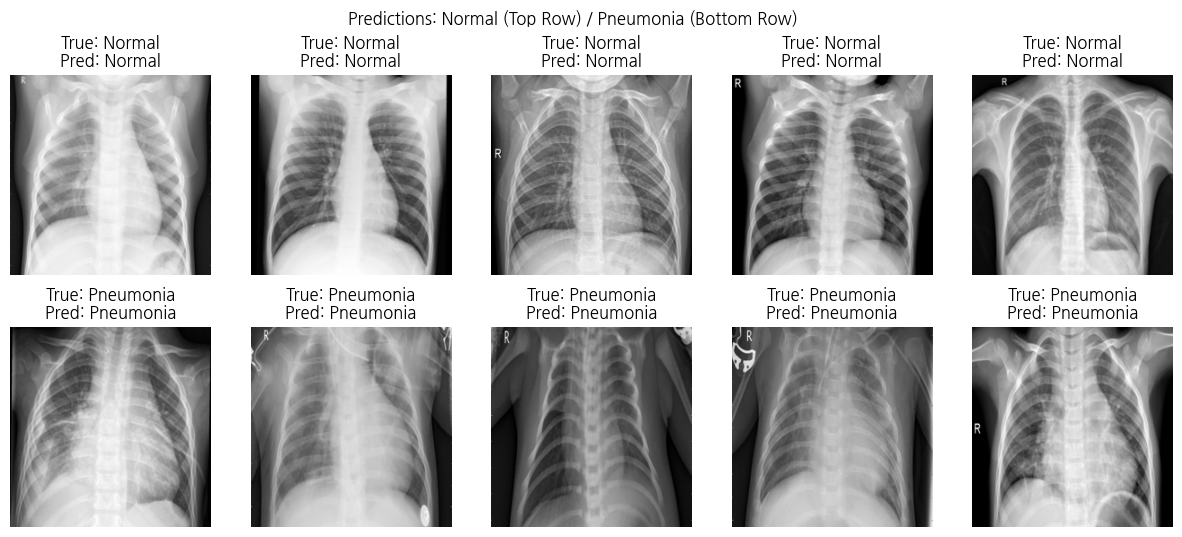

In [ ]:
# 테스트 결과 시각화 (Normal 5개, Pneumonia 5개)
visualize_predictions_balanced(pretrained_model, test_loader, num_samples_per_class=5)

---

# ✔️ 6. 결론

본 실습에서는 CustomCNN, Feature Extraction, Partial Fine-Tuning, Full Fine-Tuning<br>
총 4가지 모델을 비교하여 **폐렴 분류 성능을 분석**하였다. <br><br>

1) **CustomCNN 모델(정확도 84.62%)**은 Pneumonia 클래스는 높은 성능을 보였으나, <br>
Normal 클래스의 Recall이 낮아 정상 데이터를 놓치는 문제가 발생하였다. <br><br>

2) **Feature Extraction 모델(정확도 83.17%)**은 CustomCNN과 유사한 성능을 보였으며,<br>
Normal 클래스의 Recall이 개선되었으나 Precision이 낮아 오탐이 증가하였다.
<br><br>
3) **Partial Fine-Tuning 모델(정확도 91.83%)**은 두 클래스 모두 균형 잡힌 성능을 보이며,<br>
특히 Normal 클래스의 Recall이 86.32%로 증가하여 폐렴이 아닌 정상 데이터도 더 정확하게 예측할 수 있었다.<br>
<br>

4) **Full Fine-Tuning 모델(정확도 93.59%)**은 모든 실험 중 가장 높은 성능을 기록하였으며,<br>
두 클래스 모두 높은 Precision과 Recall을 달성하여 일반화 성능이 우수한 모델로 평가되었다.
<br><br>
결과적으로, **Full Fine-Tuning 모델이 가장 높은 정확도와 균형 잡힌 성능**을 보여 폐렴 분류 문제에서 최적의 모델로 판단된다.